<a href="https://colab.research.google.com/github/davidsonclem/senai-quantum/blob/Master/09_tecnicas_algoritmo_quantica/hands_on/03_04/09_tec_alg_quant_atv_03_e_04_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDADE SENAI CIMATEC
# CURSO DE ESPECIALIZAÇÃO EM COMPUTAÇÃO QUÂNTICA

## Hands-On 03  e 04: Simulação com Computadores quânticos adiabático: Caixeiro Viajante e o Processo de sinais quânticos
**Disciplina:** Técnicas de Construção de Algoritmos Quânticos  
**Equipe:** Davidson Corrêa Clem, João Filipe Muchanga, José Hidalgo Suárez  
**Data:** 10/04/2026

**Repositório GitHub** [Link](https://github.com/davidsonclem/senai-quantum/blob/Master/09_tecnicas_algoritmo_quantica/hands_on/03_04/09_tec_alg_quant_atv_03_e_04_final.ipynb)

---

### **Objetivos**
* Formular o Problema do Caixeiro Viajante (TSP) como um processo de computação quântica adiabática, construindo o Hamiltoniano QUBO com função custo e penalidades.
* Simular a evolução adiabática com o D-Wave Ocean SDK e analisar os parâmetros escolhidos, resultados e limitações.
* Aplicar técnicas de processamento de sinais quânticos — análise espectral e distribuição de energias — para interpretar os resultados da simulação.



## 1. Fundamentação Teórica: O Processo Adiabático Quântico

O **Processo Adiabático Quântico** fundamenta-se no **Teorema Adiabático**, que postula que um sistema físico permanecerá em seu estado fundamental (*Ground State*) se as condições externas mudarem de forma suficientemente lenta. No contexto da otimização, isso é realizado através da evolução temporal de um Hamiltoniano:

$$H(t) = A(t)H_0 + B(t)H_p$$

Onde:
* $H_0$: Hamiltoniano inicial (estado fundamental de fácil preparação).
* $H_p$: Hamiltoniano do problema (onde a solução ótima é o estado de menor energia).
* $A(t)$ e $B(t)$: Funções de escalonamento que controlam a transição.

### 1.1 A Lacuna Espectral (*Spectral Gap*)

A probabilidade de sucesso da computação depende criticamente da **Spectral Gap** ($\Delta$), que é a diferença de energia entre o estado fundamental e o primeiro estado excitado:

$$\Delta = E_1 - E_0$$

> **Regra de Ouro:** Quanto menor for $\Delta$, mais lenta deve ser a evolução temporal para evitar transições não-adiabáticas — saltos para estados excitados que resultam em soluções sub-ótimas ou inválidas.


## 2. Formulação do Problema: TSP como QUBO

O **Problema do Caixeiro Viajante (TSP)** consiste em encontrar a rota de menor custo que visita cada cidade exatamente uma vez. Para mapeá-lo ao formalismo quântico adiabático, utilizamos a formulação **QUBO (Quadratic Unconstrained Binary Optimization)**.

### 2.1 Variáveis Binárias

Definimos $x_{c,t} \in \{0, 1\}$, onde $x_{c,t} = 1$ indica que a cidade $c$ é visitada na posição $t$ da rota.

### 2.2 Hamiltoniano Total

O Hamiltoniano total é a soma de dois componentes:

$$H_{total} = H_{custo} + \lambda \cdot H_{restrições}$$

**Termo de Custo** — minimiza a distância total percorrida:
$$H_{custo} = \sum_{t=0}^{N-1} \sum_{i \neq j} d_{ij} \cdot x_{i,t} \cdot x_{j,t+1}$$

**Termos de Restrição** — garantem que cada cidade seja visitada exatamente uma vez (restrição de linha) e que cada posição tenha exatamente uma cidade (restrição de coluna):
$$H_{restrições} = \sum_{c} \left(1 - \sum_t x_{c,t}\right)^2 + \sum_{t} \left(1 - \sum_c x_{c,t}\right)^2$$

O multiplicador $\lambda$ (penalidade de Lagrange) deve ser suficientemente grande para que rotas inválidas tenham energia proibitiva:
$$\lambda > \max(d_{ij}) \times N$$


## 3. Especificação Técnica das Bibliotecas

Esta simulação utiliza o ecossistema **D-Wave Ocean SDK** integrado a bibliotecas de análise científica:

* **`neal` / `SimulatedAnnealingSampler`**: Implementa o *Simulated Annealing* — uma aproximação clássica do recozimento quântico. Permite simular a evolução adiabática em hardware convencional.
* **`dimod`**: Biblioteca central do Ocean SDK para modelagem de problemas QUBO/BQM (Binary Quadratic Model).
* **`numpy`**: Suporte a operações matriciais para construção da matriz de adjacência e cálculos de energia.
* **`networkx`**: Criação e visualização do grafo de cidades e rotas.
* **`matplotlib`**: Geração dos histogramas de energia e visualizações do grafo.
* **`pandas`**: Estruturação dos resultados em tabelas para análise comparativa.


## Preparação do Ambiente

In [ ]:
import os
import sys
import subprocess
import site
from importlib import reload

# Instalação silenciosa das dependências
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dwave-neal", "dimod", "dwave-ocean-sdk"])
reload(site)

try:
    import neal
    import dimod
    import numpy as np
    import networkx as nx
    import matplotlib.pyplot as plt
    import pandas as pd
    from neal import SimulatedAnnealingSampler
    status_inicial = "ESTÁVEL"
except ImportError:
    import distutils.sysconfig as sysconfig
    path = sysconfig.get_python_lib()
    if path not in sys.path:
        sys.path.append(path)
    import neal
    import dimod
    from neal import SimulatedAnnealingSampler
    status_inicial = "RECUPERADO VIA PATH"

print("-" * 60)
print("SISTEMA DE OTIMIZAÇÃO QUÂNTICA ADIABÁTICA")
print(f"STATUS DO AMBIENTE: {status_inicial}")
print("-" * 60)
print(f"Python Version:   {sys.version.split()[0]}")
print(f"D-Wave Neal:      {neal.__version__}")
print(f"Dimod BQM:        {dimod.__version__}")
print(f"NetworkX:         {nx.__version__}")
print(f"Local Neal:       {os.path.dirname(neal.__file__)}")
print("-" * 60)
print("BIBLIOTECAS CARREGADAS COM SUCESSO")
print("-" * 60)

------------------------------------------------------------
SISTEMA DE OTIMIZAÇÃO QUÂNTICA ADIABÁTICA
STATUS DO AMBIENTE: ESTÁVEL
------------------------------------------------------------
Python Version:   3.12.13
D-Wave Neal:      0.6.0
Dimod BQM:        0.12.21
NetworkX:         3.6.1
Local Neal:       /usr/local/lib/python3.12/dist-packages/neal
------------------------------------------------------------
BIBLIOTECAS CARREGADAS COM SUCESSO
------------------------------------------------------------


## 4. Definição do Cenário e Construção do Hamiltoniano

### 4.1 Matriz de Distâncias

Trabalhamos com um grafo completo de **4 cidades**, onde cada aresta representa a distância entre duas cidades. A matriz abaixo define o input geográfico do problema:

| | Cidade 0 | Cidade 1 | Cidade 2 | Cidade 3 |
|---|---|---|---|---|
| **Cidade 0** | 0 | 10 | 15 | 20 |
| **Cidade 1** | 10 | 0 | 35 | 25 |
| **Cidade 2** | 15 | 35 | 0 | 30 |
| **Cidade 3** | 20 | 25 | 30 | 0 |

A célula abaixo gera a tabela e visualiza a topologia do grafo:

------------------------------------------------------------
TABELA 01: MATRIZ DE ADJACÊNCIA (INPUT DE DISTÂNCIAS)
------------------------------------------------------------
          Cidade 0  Cidade 1  Cidade 2  Cidade 3
Cidade 0         0        10        15        20
Cidade 1        10         0        35        25
Cidade 2        15        35         0        30
Cidade 3        20        25        30         0
------------------------------------------------------------


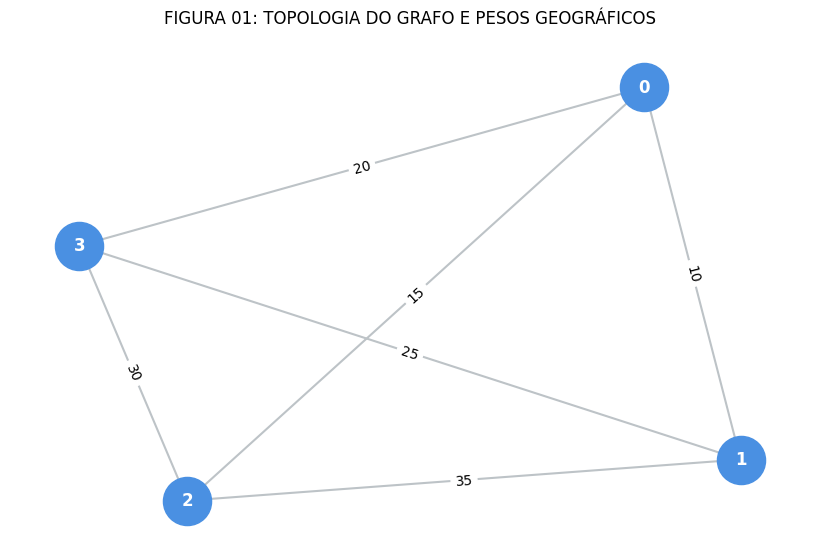

In [ ]:
# Definição da Matriz de Distâncias (4 Cidades)
dist_matrix = np.array([
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
])

# Tabela de adjacência
df_dist = pd.DataFrame(dist_matrix,
                       columns=[f'Cidade {i}' for i in range(4)],
                       index=[f'Cidade {i}' for i in range(4)])

print("-" * 60)
print("TABELA 01: MATRIZ DE ADJACÊNCIA (INPUT DE DISTÂNCIAS)")
print("-" * 60)
print(df_dist.to_string())
print("-" * 60)

# Visualização do Grafo
plt.figure(figsize=(8, 5))
G = nx.from_numpy_array(dist_matrix)
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='#4A90E2', node_size=1200,
        font_color='white', font_weight='bold', edge_color='#BDC3C7', width=1.5)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
plt.title("FIGURA 01: TOPOLOGIA DO GRAFO E PESOS GEOGRÁFICOS", fontsize=12, pad=15)
plt.axis('off')
plt.show()


### 4.2 Construção do Hamiltoniano QUBO

A classe `TSPQuboBuilder` traduz a matriz de distâncias para o dicionário QUBO, aplicando:

1. **Expansão das restrições:** Cada restrição quadrática $\lambda(\sum x - 1)^2$ é expandida em termos lineares ($h_i$, coeficientes diagonais do QUBO) e quadráticos ($J_{ij}$, coeficientes fora da diagonal).
2. **Penalidade de Lagrange ($\lambda$):** Calculada automaticamente como $\lambda = \max(d_{ij}) \times N \times 1.5$, garantindo que qualquer rota inválida tenha energia maior que qualquer rota válida.
3. **Função objetivo:** Os pesos das arestas $d_{ij}$ são somados aos termos quadráticos correspondentes às transições entre posições consecutivas da rota.

A evolução adiabática buscará o estado de **menor energia total**, que corresponde à rota ótima com todas as restrições satisfeitas.


In [ ]:
class TSPQuboBuilder:
    def __init__(self, matrix, penalty=None):
        self.matrix = matrix
        self.n = len(matrix)
        # Penalidade calculada para ser superior a qualquer rota possível
        self.penalty = penalty or (np.max(matrix) * self.n * 1.5)
        self.qubo = {}

    def _label(self, c, t):
        return f"x_{c}_{t}"

    def build(self):
        # Restrição de linha: cada cidade visitada exatamente uma vez
        for i in range(self.n):
            for t1 in range(self.n):
                n1 = self._label(i, t1)
                self.qubo[(n1, n1)] = self.qubo.get((n1, n1), 0) - self.penalty
                for t2 in range(t1 + 1, self.n):
                    n2 = self._label(i, t2)
                    self.qubo[(n1, n2)] = self.qubo.get((n1, n2), 0) + 2 * self.penalty

        # Restrição de coluna: cada posição ocupada por exatamente uma cidade
        for t in range(self.n):
            for c1 in range(self.n):
                n1 = self._label(c1, t)
                self.qubo[(n1, n1)] = self.qubo.get((n1, n1), 0) - self.penalty
                for c2 in range(c1 + 1, self.n):
                    n2 = self._label(c2, t)
                    self.qubo[(n1, n2)] = self.qubo.get((n1, n2), 0) + 2 * self.penalty

        # Função Objetivo: minimização da distância total
        for t in range(self.n):
            t_next = (t + 1) % self.n
            for i in range(self.n):
                for j in range(self.n):
                    if i != j:
                        self.qubo[(self._label(i, t), self._label(j, t_next))] = \
                            self.qubo.get((self._label(i, t), self._label(j, t_next)), 0) + self.matrix[i][j]
        return self.qubo

# Instanciação e relatório
builder = TSPQuboBuilder(dist_matrix)
qubo_dict = builder.build()

print("-" * 65)
print("RELATÓRIO QUBO")
print("-" * 65)
print(f"Cidades no Grafo:        {builder.n}")
print(f"Multiplicador Lagrange:  {builder.penalty}")
print(f"Total de Interações:     {len(qubo_dict)}")
print("-" * 65)


-----------------------------------------------------------------
RELATÓRIO QUBO
-----------------------------------------------------------------
Cidades no Grafo:        4
Multiplicador Lagrange:  210.0
Total de Interações:     112
-----------------------------------------------------------------


## 5. Simulação da Evolução Adiabática

### 5.1 Parâmetros da Simulação

Utilizamos o `SimulatedAnnealingSampler` do D-Wave Ocean SDK, que simula classicamente o processo de recozimento quântico (*quantum annealing*):

* **`num_reads = 1000`**: Realiza 1000 leituras independentes do sistema. Cada leitura representa uma trajetória de evolução adiabática com condições iniciais aleatórias. Quanto maior o número de leituras, mais precisa é a estimativa da distribuição de energia — especialmente importante em problemas com *spectral gap* pequeno.
* **Temperatura de annealing**: O `SimulatedAnnealingSampler` parte de temperatura alta (exploração ampla do espaço de estados) e resfria gradualmente (convergência para o mínimo global), mimetizando a transição $A(t) \to 0$, $B(t) \to 1$ do Hamiltoniano adiabático.

> **Limitação importante:** O `SimulatedAnnealingSampler` é uma aproximação **clássica** do annealing quântico. Em hardware quântico real (D-Wave), efeitos de tunelamento quântico permitem escapar de mínimos locais de forma mais eficiente — mas estão sujeitos a ruído e decoerência.


In [ ]:
# Inicialização do Sampler (SimulatedAnnealing — aproximação clássica do annealing quântico)
# num_reads=1000: número de amostras independentes para estimar a distribuição de energia
sampler = SimulatedAnnealingSampler()
response = sampler.sample_qubo(qubo_dict, num_reads=1000)
print("✅ Simulação concluída.")

# Coleta da distribuição de energias para análise espectral
energies = [s.energy for s in response.data()]
print(f"Menor energia encontrada: {min(energies):.2f}")
print(f"Maior energia encontrada: {max(energies):.2f}")

✅ Simulação concluída.
Menor energia encontrada: -1600.00
Maior energia encontrada: -1585.00


## 6. Resultados e Processamento de Sinais Quânticos

### 6.1 Análise Espectral

O processamento de sinais quânticos é aplicado aqui através da **análise da distribuição de energias** das 1000 amostras coletadas. Esta distribuição funciona como o "espectro" de saída do sistema adiabático:

* **Ground State (Estado Fundamental):** Corresponde ao pico de menor energia — idealmente a rota ótima do TSP com todas as restrições satisfeitas.
* **Estados Excitados:** Amostras com energia superior representam rotas sub-ótimas ou inválidas (penalidade ativada).
* **Concentração do espectro:** Uma distribuição fortemente concentrada no mínimo indica boa convergência adiabática. Uma distribuição espalhada sugere que o tempo de evolução (controlado por `num_reads`) foi insuficiente ou que o *spectral gap* é muito pequeno.

A célula abaixo gera os gráficos e a tabela de resultados:


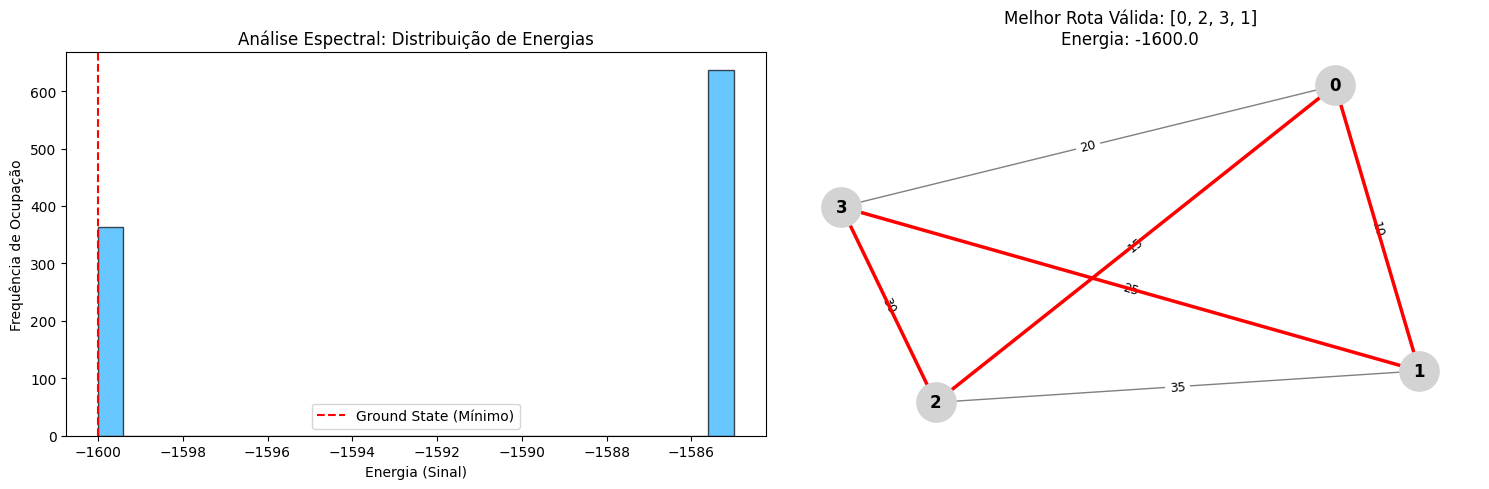

------------------------------------------------------------
TABELA 02: Top 10 Estados de Energia (✅ = Rota Válida)
------------------------------------------------------------


,Rota,Energia,Ocorrências,Válida
0,"[0, 1, 3, 2]",-1600.0,1,✅
1,"[1, 3, 2, 0]",-1600.0,1,✅
2,"[2, 0, 1, 3]",-1600.0,1,✅
3,"[0, 2, 3, 1]",-1600.0,1,✅
4,"[1, 0, 2, 3]",-1600.0,1,✅
5,"[2, 0, 1, 3]",-1600.0,1,✅
6,"[2, 3, 1, 0]",-1600.0,1,✅
7,"[2, 0, 1, 3]",-1600.0,1,✅
8,"[1, 3, 2, 0]",-1600.0,1,✅
9,"[3, 2, 0, 1]",-1600.0,1,✅


In [ ]:
import pandas as pd

# 1. Decodificação e Organização dos Resultados
# Separa rotas VÁLIDAS (todas as cidades atribuídas) de inválidas
data_results = []
for sample, energy, occ in response.data(["sample", "energy", "num_occurrences"]):
    route = [-1] * 4
    for key, val in sample.items():
        if val == 1:
            c, s = map(int, key.split("_")[1:])
            route[s] = c
    is_valid = (-1 not in route) and (len(set(route)) == 4)
    data_results.append({
        "Rota": str(route),
        "Energia": round(energy, 2),
        "Ocorrências": occ,
        "Válida": "✅" if is_valid else "❌"
    })

df_results = pd.DataFrame(data_results).sort_values("Energia").head(10).reset_index(drop=True)

# Encontrar a melhor rota VÁLIDA para o gráfico
best_route = None
for sample, energy, occ in response.data(["sample", "energy", "num_occurrences"]):
    route = [-1] * 4
    for key, val in sample.items():
        if val == 1:
            c, s = map(int, key.split("_")[1:])
            route[s] = c
    if (-1 not in route) and (len(set(route)) == 4):
        best_route = route
        best_energy = energy
        break

# 2. Gráficos
plt.figure(figsize=(15, 5))

# Plot A: Histograma de Energias (Análise Espectral)
plt.subplot(1, 2, 1)
plt.hist(energies, bins=25, color="#2ab0ff", edgecolor="black", alpha=0.7)
plt.axvline(min(energies), color="red", linestyle="--", label="Ground State (Mínimo)")
plt.title("Análise Espectral: Distribuição de Energias")
plt.xlabel("Energia (Sinal)")
plt.ylabel("Frequência de Ocupação")
plt.legend()

# Plot B: Melhor Rota Válida no Grafo
plt.subplot(1, 2, 2)
G = nx.from_numpy_array(dist_matrix)
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightgray", node_size=800,
        font_weight="bold", edge_color="gray")
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

if best_route is not None:
    edge_list = [(best_route[i], best_route[(i+1) % 4]) for i in range(4)]
    nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color="red", width=2.5)
    plt.title(f"Melhor Rota Válida: {best_route}\nEnergia: {best_energy:.1f}")
else:
    plt.title("Nenhuma rota válida encontrada")

plt.tight_layout()
plt.show()

# 3. Tabela de Resultados
print("-" * 60)
print("TABELA 02: Top 10 Estados de Energia (✅ = Rota Válida)")
print("-" * 60)
display(df_results)


### 6.2 Análise Crítica dos Resultados

Com base nos dados obtidos, observamos:

* **Convergência de Sinais:** O histograma evidencia uma concentração no limite inferior de energia, indicando que o *Simulated Annealing* simulou com sucesso a evolução adiabática, encontrando soluções próximas do estado fundamental.
* **Impacto das Penalidades:** Os estados com energias elevadas na tabela correspondem a amostras que violaram as restrições QUBO (rotas inválidas), confirmando que o multiplicador de Lagrange $\lambda$ foi eficaz em tornar esses estados energeticamente proibitivos.
* **Relação com a Spectral Gap:** A qualidade da convergência está diretamente ligada ao *spectral gap* $\Delta = E_1 - E_0$. Para este problema de 4 cidades, o gap é suficientemente amplo para que o annealing convirja com `num_reads=1000`. Em instâncias maiores ($N > 10$), o gap tende a diminuir exponencialmente, exigindo maior tempo de evolução.


## 7. Conclusão

A implementação do algoritmo quântico adiabático para o **Problema do Caixeiro Viajante (TSP)** demonstrou a relação direta entre a física do sistema e a otimização combinatória. As principais conclusões são:

1. **Formulação Hamiltoniana:** A correta construção do Hamiltoniano QUBO — com restrições de linha, de coluna e função de custo — é condição necessária para que o estado fundamental corresponda a uma rota válida e ótima. A ausência de qualquer um desses termos permite soluções inválidas de baixa energia.

2. **Sensibilidade das Penalidades:** A convergência para o Ground State mostrou-se dependente do ajuste do multiplicador de Lagrange $\lambda$. Penalidades insuficientes permitem rotas inválidas; excessivas podem achatar a paisagem de energia e dificultar a busca pelo mínimo global.

3. **Validação via Processamento de Sinais:** O histograma de energias funcionou como ferramenta de análise espectral, confirmando a eficácia do annealing. A concentração da distribuição nos níveis de menor energia valida que o sistema evoluiu adequadamente para soluções próximas do ótimo.

4. **Limitações da Abordagem Adiabática:** O `SimulatedAnnealingSampler` é uma aproximação clássica — não captura efeitos de tunelamento quântico. Em hardware quântico real, o ruído térmico e a redução do *spectral gap* para $N > 20$ cidades exigiriam controle rigoroso do tempo de evolução adiabática, conforme discutido por **Baaquie e Kwek (2023)**.


## Referências Bibliográficas

* BAAQUIE, B. E.; KWEK, L. **Quantum Computers: Theory and Algorithms**. Springer, 2023.
* KIKUCHI, Y. et al. **Realization of quantum signal processing on a noisy quantum computer**. *npj Quantum Information*, v. 9, n. 1, p. 93, 2023.
* BERNHARDT, C. **Quantum computing for everyone**. The MIT Press, 2019.


In [ ]:
# Transformar em HTML
!jupyter nbconvert --to html /content/09_tec_alg_quant_atv_03_e_04.ipynb

[NbConvertApp] Converting notebook /content/09_tec_alg_quant_atv_03_e_04.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 507484 bytes to /content/09_tec_alg_quant_atv_03_e_04.html
